# **Turbo-Brainvoyager Network Interface - Basics 1**

In this excersice you will learn the basic commands to interact with Turbo-Brainvoyager (TBV) using the python network interface. You can download the python version of the TBV network inteface at this link: https://github.com/expyriment/expyriment-stash/tree/master/extras/expyriment_io_extras/tbvnetworkinterface

The TBV python network interface relies on the Expyriment package (https://github.com/expyriment/expyriment).


## 1. Connet to TBV using TCP-IP protocol

You need to define **HOST IP** of the PC running TBV and TBV listening **PORT** (check that in the in the master TBV settings) to start a TCP/IP connection. If you are running this script from the same PC were TBV is running then indicate **HOST='localhost'**. If you want to connect to TBV on a different PC, make sure that the two PCs are on the same subnetwork and check the IP of the TBV PC (use **ipconfig** in the commond prompt for Windows and **ipconfig getifaddr en0** or **en1** on MacOS)

In [10]:
from expyriment_io_extras.tbvnetworkinterface import TbvNetworkInterface
import warnings
warnings.filterwarnings("ignore")

HOST = 'localhost'
PORT = 55555

# try to connect to TBV
try:
    TBV = TbvNetworkInterface(HOST, PORT)
    print('\nConnected to TBV.')
    print(f'HOST: {HOST}, PORT: {PORT}\n\n')
except Exception as e:
    print(e)
    exit(1)


Connected to TBV.
HOST: localhost, PORT: 55555




## 2. Get TBV settings - Basic calls

For this demo let's use the Faces and Houses sample dataset. Load the 'NK_FFA_PPA_MNI-1.tbvj' file and start the real-time processing. After starting the processing you can run this section of the notebook. The code shows how to get information regarding the data that is currently processed. Note that at each call of the network plugin, both the desire output and the retrieval time is returned.

In [11]:
watch_folder, rt = TBV.get_watch_folder()
print('TBV WatchFolder: ', watch_folder)
print(rt)

target_folder, rt = TBV.get_target_folder()
print('TBV TargetFolder: ', target_folder)
print(rt)

feedback_folder, rt = TBV.get_feedback_folder()
print('TBV FeedbackFolder: ', feedback_folder)

progect_name, rt = TBV.get_project_name()
print('TBV FeedbackFolder: ', progect_name)


TBV WatchFolder:  D:/ABMTNF/MRI-pilots/pilot3/20260203.NATMAS_20260203_ABMTNF_PILOT3.ses1/TBVFiles/../
0
TBV TargetFolder:  D:/ABMTNF/MRI-pilots/pilot3/20260203.NATMAS_20260203_ABMTNF_PILOT3.ses1/TBVFiles/TargetFolder/svm_float_check/
0
TBV FeedbackFolder:  D:/ABMTNF/MRI-pilots/pilot3/20260203.NATMAS_20260203_ABMTNF_PILOT3.ses1/TBVFiles/TargetFolder/svm_float_check/
TBV FeedbackFolder:  neurofeedback-run-1_offline_extra_session


## 3. Get Design Information

The network interface gives also access to several imformation regarding dimensionatily of the data and the design matrix. Try plotting the full design matrix and understand the predictors order. You can double check that from the TBV output files by opening the '*WithCounfounds.rtc' file in the current TargetFolder. Note that the values of the design matrix ar only available during the online preprocessing.

TBV Expected number of time points:  616
Functional data dimensions:  [90, 90, 48]
Number of predictors:  11
Number of confound predictors:  8
Current protocol condition:  0
Current time point:  572


Text(0.5, 1.0, 'First predictor values up to the current time point 572')

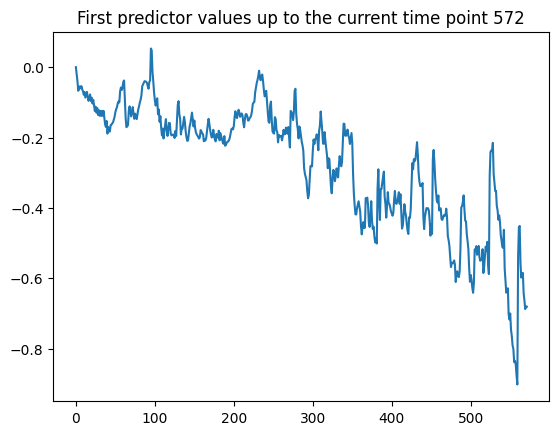

In [35]:
import matplotlib.pyplot as plt

expected_number_of_time_point, rt = TBV.get_expected_nr_of_time_points()
print('TBV Expected number of time points: ', expected_number_of_time_point)

func_dim, rt =  TBV.get_dims_of_functional_data()
print('Functional data dimensions: ', func_dim)

nr_pred, rt =  TBV.get_full_nr_of_predictors()
print('Number of predictors: ', nr_pred)

nr_conf, rt =  TBV.get_nr_of_confound_predictors()
print('Number of confound predictors: ', nr_conf)

current_cond, rt = TBV.get_current_protocol_condition()
print('Current protocol condition: ', current_cond)

current_time_point, rt = TBV.get_current_time_point() # 1-based!!!
print('Current time point: ', current_time_point)

# get values of the first predictor of the design matrix up to the current time point

# plot design matrix values
pred_values = []
for i in range(current_time_point):
    pred_values.append(TBV.get_value_of_design_matrix(5,i)[0])

#print(pred_values) 

fig, ax = plt.subplots()
ax.plot(pred_values)
ax.set_title(f'First predictor values up to the current time point {current_time_point}')



## 4. Read ROI Data

After loading or defining a ROI, it is possible to access ROI data and statistics using the network interface. The code below shows how to get mean raw and detrended BOLD value of the ROI at the current time point, and all extisting raw and detrended mean values available up to the current time point. Note that network interface collects ROI data as soon as the ROI becomes available. Therefore, to make sure that you can access all data from the first time point onwards, you need to use the 'Preload' button so that TBV will automatically load the selected ROI when starting the preprocessing. Try loading multiple ROIs and getting the mean vaules for all of them. Compare exsisting means and existing detrended means of the ROIs. 

TBV number of loaded ROI:  1
Mean of ROI 0:  3850.61669921875
Detrended mean of ROI 0:  3850.61669921875
Current time point:  306
Length of the average time course data:  306


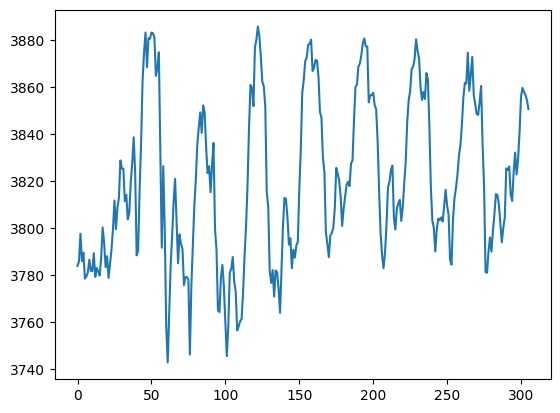

In [27]:
nr_roi, rt = TBV.get_nr_of_rois()
print('TBV number of loaded ROI: ', nr_roi)

if nr_roi > 0:

    roi_mean, rt = TBV.get_mean_of_roi(0)
    print(f'Mean of ROI {0}: ', roi_mean)
    roi_detrended_mean, rt = TBV.get_detrended_value_of_roi(0)
    print(f'Detrended mean of ROI {0}: ', roi_detrended_mean)
    print('Current time point: ', TBV.get_current_time_point()[0])

    existing_mean, rt = TBV.get_existing_means_of_roi(0, TBV.get_current_time_point()[0]-1) # time point index should be 0-based in this call!
    print('Length of the average time course data: ',len(existing_mean))
    fig, ax = plt.subplots()
    ax.plot(existing_mean)

else:
    print('No ROI available. Please load a ROI before running this section')



## 5. Read ROI Statistics

Search among the list of methods of the python network interface class how to get the average beta value of the current ROI for each experimental condition. Note that this values are available only during the real-time preprocessing

In [29]:
nr_roi, rt = TBV.get_nr_of_rois()
print('TBV number of loaded ROI: ', nr_roi)

if nr_roi > 0:

    # add code here
    pass

else:
    print('No ROI available. Please load a ROI before running this section')



TBV number of loaded ROI:  1
